# Corner held-out far-to-near training-data sweep

This notebook runs a corner held-out far-to-near data-amount sweep for the transmon-cross inverse model.

The idea is:

1. choose the held-out validation and test region from one corner of geometry space,
2. keep that corner out of the training pool completely,
3. fit scalers only on the non-held-out training pool,
4. retrain the forward surrogate on that same non-held-out training pool,
5. rank the training candidates by distance from the held-out test corner,
6. train first on the farthest samples,
7. add closer samples as the training fraction increases,
8. plot the learning curve and also plot the geometry-space spread at every fraction.

The collaborator's example corner was around claw length 50, ground spacing 2, and cross length 420 by eye. Those first two values are outside the SQuADDS range used in the manuscript, so this notebook clips the requested corner to the nearest reachable corner in the actual dataset unless you change the values below.

The important interpretation is that 100% means 100% of the non-held-out training pool. The validation and test corner samples are still excluded.


In [1]:
from __future__ import annotations

import gc
import json
import os
import sys
import zipfile
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.models import load_model


tf.keras.backend.set_floatx("float32")

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

# This notebook can be run either from the transmon experiment folder or from the
# repo root. The block below tries both so local paths do not need hard-coding.
HERE = Path.cwd()
EXPERIMENT_RELATIVE = Path("experiments/model_predict_qubit_TransmonCross_Hamiltonian_params")

if (HERE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE
elif (HERE / EXPERIMENT_RELATIVE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE / EXPERIMENT_RELATIVE
else:
    raise FileNotFoundError(
        "Could not find the transmon-cross metadata file. "
        "Run this notebook from the repo root or from the transmon experiment folder."
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from parameters_surrogate_defined_loss import (  # noqa: E402
    EPOCHS,
    MODEL_DIR as PARAM_MODEL_DIR,
    SCALERS_DIR as PARAM_SCALERS_DIR,
    TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS,
)

METADATA_DIR = EXPERIMENT_DIR / "metadata"
METADATA_PATH = METADATA_DIR / "qubit-TransmonCross-Hamiltonian_params.json"
OUT_PATH = EXPERIMENT_DIR / "data_amount_sweep_corner_far_to_near_clean.csv"
PLOT_DIR = EXPERIMENT_DIR / "plots" / "corner_far_to_near_sweep_clean"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path(PARAM_MODEL_DIR)
SCALERS_DIR = Path(PARAM_SCALERS_DIR)
SURROGATE_MODEL_PATH = MODEL_DIR / "best_keras_model_model2_surrogate.keras"
COMBINED_MODEL_PATH = MODEL_DIR / "surrogate_loss_2in_3out_best_model.keras"
INVERSE_MODEL_PATH = MODEL_DIR / "surrogate_loss_2in_3out_best_model.keras"
CORNER_SURROGATE_MODEL_PATH = MODEL_DIR / "corner_far_to_near_surrogate.keras"
ACTIVE_SURROGATE_MODEL_PATH = SURROGATE_MODEL_PATH

# Retrain the forward surrogate on the same non-held-out training pool used below.
# This avoids using a saved surrogate that may have seen the new corner test region.
RETRAIN_SURROGATE_FOR_CORNER_SPLIT = True

# Fractions of the training pool to use. These mirror the script version.
FRACTIONS = (0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00)
SEEDS = (0, 1, 2)

# The collaborator named this corner by eye from Fig. 2. claw=50 and ground=2
# are outside the actual SQuADDS-derived ranges, so the notebook clips this to
# the nearest valid corner after loading the data.
REQUESTED_TEST_CORNER_UM = np.array([50.0, 2.0, 420.0])

# I keep test and validation in the same corner region so the validation/test
# losses answer the same question: how well do we learn near the held-out corner?
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15

# Run the training sweep. Set this to False if the CSV already exists and you
# only want to remake the plots.
RUN_SWEEP = True

EPS = 1e-12

# Simple paper-ish colors used elsewhere in the repo figures.
GREEN = "#3D8B3D"
GREEN_LIGHT = "#E8F5E8"
ORANGE = "#E87A00"
ORANGE_LIGHT = "#FFF4E6"
PURPLE = "#7B68AE"
PURPLE_LIGHT = "#E8E4F0"
BLUE = "#3F6F8B"
GREY = "#B8B8B8"
DARK = "#222222"


In [2]:
# -----------------------------------------------------------------------------
# Data loading and scaling helpers
# -----------------------------------------------------------------------------

@dataclass
class Scaler:
    min_: np.ndarray
    max_: np.ndarray

    @property
    def range_(self) -> np.ndarray:
        return np.maximum(self.max_ - self.min_, EPS)

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (x - self.min_) / self.range_

    def inverse_transform(self, x: np.ndarray) -> np.ndarray:
        return x * self.range_ + self.min_


def parse_um(value: object) -> float:
    text = str(value).strip()
    for suffix in ("um", "µm", "μm"):
        if text.endswith(suffix):
            return float(text[: -len(suffix)])
    return float(text)


def load_arrays() -> tuple[np.ndarray, np.ndarray]:
    """Load Hamiltonian targets and geometry values from the SQuADDS metadata."""
    data = json.loads(METADATA_PATH.read_text())
    hamiltonian = []
    geometry = []

    for row in data:
        h = row["Hamiltonian_params"]
        opts = row["design"]["design_options"]
        readout = opts["connection_pads"]["readout"]

        hamiltonian.append(
            [
                float(h["qubit_frequency_GHz"]),
                float(h["anharmonicity_MHz"]),
            ]
        )
        geometry.append(
            [
                parse_um(readout["claw_length"]),
                parse_um(readout["ground_spacing"]),
                parse_um(opts["cross_length"]),
            ]
        )

    return np.asarray(hamiltonian, dtype=np.float64), np.asarray(geometry, dtype=np.float64)


def choose_corner_heldout_split(
    geometry_um: np.ndarray,
    requested_corner_um: np.ndarray,
    test_fraction: float = 0.15,
    val_fraction: float = 0.15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Choose a held-out corner region and keep the remaining points as training candidates.

    The requested corner is clipped to the actual data range because the collaborator's
    approximate values were read by eye and can sit slightly outside the sampled range.
    """
    n_rows = len(geometry_um)
    n_test = int(np.ceil(test_fraction * n_rows))
    n_val = int(np.ceil(val_fraction * n_rows))

    geom_min = geometry_um.min(axis=0)
    geom_max = geometry_um.max(axis=0)
    clipped_corner_um = np.clip(requested_corner_um, geom_min, geom_max)

    corner_scaler = Scaler(geom_min, geom_max)
    geometry_scaled = corner_scaler.transform(geometry_um)
    corner_scaled = corner_scaler.transform(clipped_corner_um.reshape(1, -1))[0]

    corner_distance = np.linalg.norm(geometry_scaled - corner_scaled, axis=1)
    near_corner_order = np.argsort(corner_distance)
    
    corner_idx = near_corner_order[:n_test + n_val]
    rng = np.random.default_rng(42)
    rng.shuffle(corner_idx)
    
    test_idx = corner_idx[:n_test]
    val_idx = corner_idx[n_test:]
    train_pool_idx = near_corner_order[n_test + n_val:]

    return train_pool_idx, val_idx, test_idx, clipped_corner_um, corner_distance


def rank_training_far_to_near(
    geometry_scaled: np.ndarray,
    train_pool_idx: np.ndarray,
    test_idx: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Rank the training pool by distance to the held-out test corner.

    The first samples are the farthest from the testing data. As the fraction
    increases, the subset grows toward the testing data.
    """
    train_geom = geometry_scaled[train_pool_idx]
    test_geom = geometry_scaled[test_idx]

    nn = NearestNeighbors(n_neighbors=1).fit(test_geom)
    train_to_test_distance = nn.kneighbors(train_geom, return_distance=True)[0][:, 0]
    far_to_near_order = np.argsort(-train_to_test_distance)

    return far_to_near_order, train_to_test_distance


def scaler_from_artifacts(
    values: np.ndarray,
    columns: list[str],
    path_patterns: list[str],
    label: str,
) -> tuple[Scaler, list[str]]:
    """Load per-column MinMaxScaler ranges when present, otherwise fit on metadata."""
    mins = []
    maxs = []
    sources = []

    for i, col in enumerate(columns):
        loaded = None
        source = None
        for pattern in path_patterns:
            candidate = SCALERS_DIR / pattern.format(col=col)
            if candidate.exists():
                loaded = joblib.load(candidate)
                source = str(candidate)
                break

        if loaded is not None:
            mins.append(float(np.asarray(loaded.data_min_).reshape(-1)[0]))
            maxs.append(float(np.asarray(loaded.data_max_).reshape(-1)[0]))
            sources.append(source)
        else:
            mins.append(float(np.min(values[:, i])))
            maxs.append(float(np.max(values[:, i])))
            sources.append(f"metadata fallback: {label}.{col}")

    return Scaler(np.asarray(mins), np.asarray(maxs)), sources


In [3]:
# -----------------------------------------------------------------------------
# Build the held-out corner split and model-space scalers
# -----------------------------------------------------------------------------

h_raw, geom_raw_um = load_arrays()
geom_raw_si = geom_raw_um * 1e-6

HAMILTONIAN_COLUMN_NAMES = (METADATA_DIR / "X_names").read_text().splitlines()
QISKIT_PARAM_NAMES = np.load(METADATA_DIR / "y_columns.npy", allow_pickle=True).astype(str).tolist()

train_pool_idx, val_idx, test_idx, clipped_corner_um, corner_distance = choose_corner_heldout_split(
    geom_raw_um,
    REQUESTED_TEST_CORNER_UM,
    TEST_FRACTION,
    VAL_FRACTION,
)

# Make sure the held-out corner data never leaks into the training pool.
assert len(np.intersect1d(train_pool_idx, val_idx)) == 0
assert len(np.intersect1d(train_pool_idx, test_idx)) == 0
assert len(np.intersect1d(val_idx, test_idx)) == 0

# The split/ranking scaler is only for choosing far-to-near geometry coverage.
# It is fit on the non-held-out training pool only.
geom_split_scaler = Scaler(
    geom_raw_um[train_pool_idx].min(axis=0),
    geom_raw_um[train_pool_idx].max(axis=0),
)
geom_scaled = geom_split_scaler.transform(geom_raw_um)

far_to_near_order, train_to_test_distance = rank_training_far_to_near(
    geom_scaled,
    train_pool_idx,
    test_idx,
)

# For this corner-held-out experiment, fit all model-space scalers on the
# non-held-out training pool only. This avoids leaking the held-out validation
# and test corner into preprocessing.
h_model_scaler = Scaler(
    h_raw[train_pool_idx].min(axis=0),
    h_raw[train_pool_idx].max(axis=0),
)
geom_model_scaler = Scaler(
    geom_raw_si[train_pool_idx].min(axis=0),
    geom_raw_si[train_pool_idx].max(axis=0),
)

h_model_scaled = h_model_scaler.transform(h_raw).astype("float32")
geom_inverse_scaled = geom_model_scaler.transform(geom_raw_si).astype("float32")
geom_surrogate_scaled = geom_model_scaler.transform(geom_raw_si).astype("float32")

# The inverse output and surrogate input now use the same training-pool scaler.
# So no conversion is needed between the two geometry spaces.
scale_a = np.ones(len(QISKIT_PARAM_NAMES), dtype="float32")
scale_b = np.zeros(len(QISKIT_PARAM_NAMES), dtype="float32")

print(f"Loaded {len(h_raw)} total samples")
print(f"Training pool: {len(train_pool_idx)}")
print(f"Validation corner: {len(val_idx)}")
print(f"Test corner: {len(test_idx)}")
print()
print("Split check passed:")
print("  train/val overlap:", len(np.intersect1d(train_pool_idx, val_idx)))
print("  train/test overlap:", len(np.intersect1d(train_pool_idx, test_idx)))
print("  val/test overlap:", len(np.intersect1d(val_idx, test_idx)))
print("  100% means all non-held-out training-pool samples, not all samples.")
print()
print("Requested corner [claw, ground, cross] µm:", REQUESTED_TEST_CORNER_UM)
print("Nearest usable dataset corner [claw, ground, cross] µm:", clipped_corner_um)
print()
print("Geometry ranges in the full metadata:")
for name, lo, hi in zip(["claw_length", "ground_spacing", "cross_length"], geom_raw_um.min(axis=0), geom_raw_um.max(axis=0)):
    print(f"  {name:15s}: {lo:8.3f} to {hi:8.3f} µm")
print()
print("Scalers fit on training pool only:")
for name, lo, hi in zip(HAMILTONIAN_COLUMN_NAMES, h_model_scaler.min_, h_model_scaler.max_):
    print(f"  Hamiltonian {name}: {lo:.6g} to {hi:.6g}")
for name, lo, hi in zip(QISKIT_PARAM_NAMES, geom_model_scaler.min_, geom_model_scaler.max_):
    print(f"  Geometry {name}: {lo:.6g} to {hi:.6g} SI units")
print()
print("Keras artifacts:")
print(f"  saved surrogate model:    {SURROGATE_MODEL_PATH}")
print(f"  corner surrogate model:   {CORNER_SURROGATE_MODEL_PATH}")
print(f"  combined reference model: {COMBINED_MODEL_PATH}")
print(f"  inverse reference model:  {INVERSE_MODEL_PATH}")
print()
print("Scaler conversion inverse -> surrogate:")
for name, a, b in zip(QISKIT_PARAM_NAMES, scale_a, scale_b):
    print(f"  {name}: a={a:.6g}, b={b:.6g}")


Loaded 1934 total samples
Training pool: 1352
Validation corner: 291
Test corner: 291

Split check passed:
  train/val overlap: 0
  train/test overlap: 0
  val/test overlap: 0
  100% means all non-held-out training-pool samples, not all samples.

Requested corner [claw, ground, cross] µm: [ 50.   2. 420.]
Nearest usable dataset corner [claw, ground, cross] µm: [ 70.    4.1 420. ]

Geometry ranges in the full metadata:
  claw_length    :   70.000 to  400.000 µm
  ground_spacing :    4.100 to   10.000 µm
  cross_length   :   90.000 to  420.000 µm

Scalers fit on training pool only:
  Hamiltonian qubit_frequency_GHz: 3.21853 to 7.12659
  Hamiltonian anharmonicity_MHz: -525.818 to -88.9577
  Geometry design_options.connection_pads.readout.claw_length: 7e-05 to 0.0004 SI units
  Geometry design_options.connection_pads.readout.ground_spacing: 4.1e-06 to 1e-05 SI units
  Geometry design_options.cross_length: 9e-05 to 0.00042 SI units

Keras artifacts:
  saved surrogate model:    /home/olivias

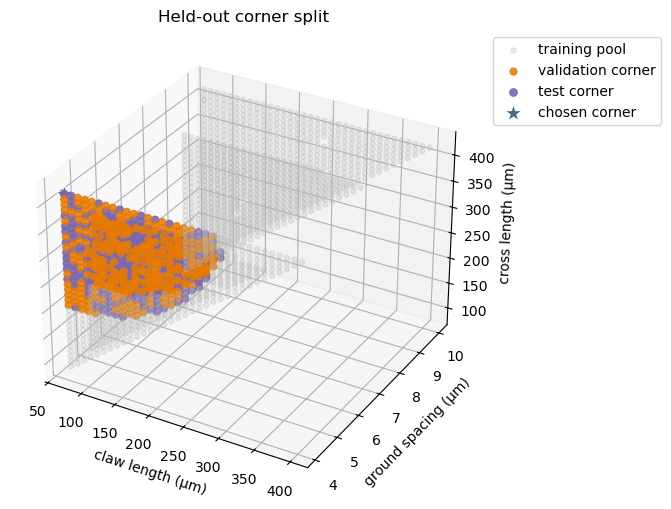

In [4]:
# -----------------------------------------------------------------------------
# Quick plot of the corner split before training
# -----------------------------------------------------------------------------

fig = plt.figure(figsize=(6.4, 5.4))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    geom_raw_um[train_pool_idx, 0],
    geom_raw_um[train_pool_idx, 1],
    geom_raw_um[train_pool_idx, 2],
    s=14,
    c=GREY,
    alpha=0.28,
    label="training pool",
)
ax.scatter(
    geom_raw_um[val_idx, 0],
    geom_raw_um[val_idx, 1],
    geom_raw_um[val_idx, 2],
    s=24,
    c=ORANGE,
    alpha=0.85,
    label="validation corner",
)
ax.scatter(
    geom_raw_um[test_idx, 0],
    geom_raw_um[test_idx, 1],
    geom_raw_um[test_idx, 2],
    s=28,
    c=PURPLE,
    alpha=0.90,
    label="test corner",
)
ax.scatter(
    [clipped_corner_um[0]],
    [clipped_corner_um[1]],
    [clipped_corner_um[2]],
    s=180,
    marker="*",
    c=BLUE,
    edgecolor="white",
    linewidth=0.8,
    label="chosen corner",
)

ax.set_xlabel("claw length (µm)")
ax.set_ylabel("ground spacing (µm)")
ax.set_zlabel("cross length (µm)")
ax.set_title("Held-out corner split")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)
fig.tight_layout()
fig.savefig(PLOT_DIR / "corner_split_3d.pdf", bbox_inches="tight")
fig.savefig(PLOT_DIR / "corner_split_3d.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:

def read_keras_config(path: Path) -> dict:
    with zipfile.ZipFile(path) as zf:
        return json.loads(zf.read("config.json"))


def extract_reference_specs(combined_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(combined_path)
    layers = cfg["config"]["layers"]
    inverse_cfg = next(
        layer for layer in layers
        if layer.get("class_name") == "Sequential" and layer.get("config", {}).get("name") == "inverse_model"
    )
    compile_cfg = cfg.get("compile_config") or {}
    return inverse_cfg["config"], compile_cfg


def _initializer_from_config(config: dict | None, seed: int | None):
    if not config:
        return None
    cfg = json.loads(json.dumps(config))
    if seed is not None and isinstance(cfg.get("config"), dict) and "seed" in cfg["config"]:
        cfg["config"]["seed"] = seed
    try:
        return tf.keras.initializers.deserialize(cfg)
    except Exception:
        class_name = cfg.get("class_name")
        if class_name == "HeNormal":
            return tf.keras.initializers.HeNormal(seed=cfg.get("config", {}).get("seed"))
        if class_name == "Zeros":
            return tf.keras.initializers.Zeros()
        return tf.keras.initializers.get(class_name)


def _regularizer_from_config(config: dict | None):
    if not config:
        return None
    try:
        return tf.keras.regularizers.deserialize(config)
    except Exception:
        if config.get("class_name") == "L2":
            return tf.keras.regularizers.l2(config.get("config", {}).get("l2", 0.01))
        raise


def build_inverse_from_reference(input_dim: int, seed: int) -> Sequential:
    tf.keras.utils.set_random_seed(seed)
    model = Sequential(name=REFERENCE_INVERSE_CONFIG.get("name", "inverse_model"))

    for layer_idx, layer_cfg in enumerate(REFERENCE_INVERSE_CONFIG["layers"]):
        class_name = layer_cfg["class_name"]
        cfg = layer_cfg["config"]

        if class_name == "InputLayer":
            model.add(Input(shape=(input_dim,), name=cfg.get("name", "Hamiltonian_input")))
        elif class_name == "Dense":
            model.add(
                Dense(
                    cfg["units"],
                    activation=cfg.get("activation", "linear"),
                    name=cfg.get("name"),
                    kernel_initializer=_initializer_from_config(cfg.get("kernel_initializer"), seed + layer_idx),
                    bias_initializer=_initializer_from_config(cfg.get("bias_initializer"), None),
                    kernel_regularizer=_regularizer_from_config(cfg.get("kernel_regularizer")),
                    bias_regularizer=_regularizer_from_config(cfg.get("bias_regularizer")),
                )
            )
        elif class_name == "LeakyReLU":
            model.add(LeakyReLU(negative_slope=cfg.get("negative_slope", 0.01), name=cfg.get("name")))
        elif class_name == "Dropout":
            model.add(Dropout(rate=cfg.get("rate", 0.0), name=cfg.get("name")))
        else:
            raise ValueError(f"Unsupported reference layer type: {class_name}")

    return model


class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault("trainable", False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = {"scale_a": list(np.asarray(scale_a, dtype=float)), "scale_b": list(np.asarray(scale_b, dtype=float))}

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config


def qiskit_range_penalty(y_true_dummy, y_pred):
    """Penalize inverse predictions outside the scaled [0, 1] training range."""
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)


def load_frozen_surrogate():
    surrogate_model = load_model(ACTIVE_SURROGATE_MODEL_PATH, compile=False)
    surrogate_model.trainable = False
    for layer in surrogate_model.layers:
        layer.trainable = False
    return surrogate_model


def deserialize_reference_learning_rate(lr_config):
    if isinstance(lr_config, (int, float, np.integer, np.floating)):
        return float(lr_config)
    if isinstance(lr_config, str):
        try:
            return float(lr_config)
        except ValueError:
            return lr_config
    if isinstance(lr_config, dict):
        cfg = lr_config.get("config", {})
        for key in ("value", "initial_value"):
            if key in cfg and isinstance(cfg[key], (int, float, np.integer, np.floating)):
                return float(cfg[key])
        try:
            return tf.keras.optimizers.schedules.deserialize(lr_config)
        except Exception:
            if "initial_learning_rate" in cfg:
                return tf.keras.optimizers.schedules.ExponentialDecay(
                    initial_learning_rate=float(cfg["initial_learning_rate"]),
                    decay_steps=cfg.get("decay_steps", 1),
                    decay_rate=cfg.get("decay_rate", 1.0),
                    staircase=cfg.get("staircase", False),
                )
            raise
    return lr_config


def describe_learning_rate(lr) -> str:
    if isinstance(lr, (int, float, np.integer, np.floating)):
        return str(float(lr))
    if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
        return f"{lr.__class__.__name__}({lr.get_config()})"
    return str(lr)


def build_reference_optimizer():
    try:
        return tf.keras.optimizers.deserialize(REFERENCE_COMPILE_CONFIG["optimizer"])
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=REFERENCE_LEARNING_RATE)


def build_combined_model(seed: int) -> tuple[Sequential, Model]:
    tf.keras.backend.clear_session()
    surrogate_model = load_frozen_surrogate()
    inverse_model = build_inverse_from_reference(h_model_scaled.shape[1], seed=seed)

    combined_input = Input(shape=(h_model_scaled.shape[1],), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")(predicted_qiskit)
    reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)

    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )

    combined_model.compile(
        optimizer=build_reference_optimizer(),
        loss=[REFERENCE_RECONSTRUCTION_LOSS, qiskit_range_penalty],
        loss_weights=REFERENCE_LOSS_WEIGHTS,
        jit_compile=REFERENCE_JIT_COMPILE,
    )

    return inverse_model, combined_model


REFERENCE_INVERSE_CONFIG, REFERENCE_COMPILE_CONFIG = extract_reference_specs(COMBINED_MODEL_PATH)
REFERENCE_OPTIMIZER_CONFIG = REFERENCE_COMPILE_CONFIG["optimizer"]["config"]
REFERENCE_LEARNING_RATE = deserialize_reference_learning_rate(REFERENCE_OPTIMIZER_CONFIG["learning_rate"])
REFERENCE_LEARNING_RATE_LABEL = describe_learning_rate(REFERENCE_LEARNING_RATE)
REFERENCE_RECONSTRUCTION_LOSS = REFERENCE_COMPILE_CONFIG["loss"][0]
REFERENCE_LOSS_WEIGHTS = [float(v) for v in REFERENCE_COMPILE_CONFIG.get("loss_weights", [1.0, 1.0])]
REFERENCE_JIT_COMPILE = bool(REFERENCE_COMPILE_CONFIG.get("jit_compile", False))
REFERENCE_BATCH_SIZE = TRAIN_BATCH_SIZE
REFERENCE_EPOCHS = EPOCHS
REFERENCE_EARLY_STOPPING_PATIENCE = TRAIN_EARLY_STOPPING_PATIENCE

reference_dense_layers = [
    layer["config"]["units"]
    for layer in REFERENCE_INVERSE_CONFIG["layers"]
    if layer["class_name"] == "Dense"
]
print("Reference inverse dense units:", reference_dense_layers)
print("Reference optimizer: Adam")
print("Reference learning rate:", REFERENCE_LEARNING_RATE_LABEL)
print("Reference reconstruction loss:", REFERENCE_RECONSTRUCTION_LOSS)
print("Reference loss weights:", REFERENCE_LOSS_WEIGHTS)
print("Reference jit_compile:", REFERENCE_JIT_COMPILE)
print("Training epochs/batch/patience:", REFERENCE_EPOCHS, REFERENCE_BATCH_SIZE, REFERENCE_EARLY_STOPPING_PATIENCE)


Reference inverse dense units: [64, 3]
Reference optimizer: Adam
Reference learning rate: ExponentialDecay({'initial_learning_rate': 0.001, 'decay_steps': 220, 'decay_rate': 0.99, 'staircase': False, 'name': 'ExponentialDecay'})
Reference reconstruction loss: mae
Reference loss weights: [1.0, 1.0]
Reference jit_compile: True
Training epochs/batch/patience: 400 128 60


In [6]:
# -----------------------------------------------------------------------------
# Training and evaluation helpers
# -----------------------------------------------------------------------------

def fit_inverse_for_subset(
    h_subset_scaled: np.ndarray,
    h_val_scaled: np.ndarray,
    seed: int,
) -> tuple[Sequential, Model, tf.keras.callbacks.History]:
    inverse_model, combined_model = build_combined_model(seed=seed)
    dummy_train = np.zeros((len(h_subset_scaled), len(QISKIT_PARAM_NAMES)), dtype="float32")
    dummy_val = np.zeros((len(h_val_scaled), len(QISKIT_PARAM_NAMES)), dtype="float32")

    early_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=REFERENCE_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    history = combined_model.fit(
        np.asarray(h_subset_scaled, dtype="float32"),
        [np.asarray(h_subset_scaled, dtype="float32"), dummy_train],
        epochs=REFERENCE_EPOCHS,
        batch_size=REFERENCE_BATCH_SIZE,
        validation_data=(
            np.asarray(h_val_scaled, dtype="float32"),
            [np.asarray(h_val_scaled, dtype="float32"), dummy_val],
        ),
        callbacks=[early_stopping],
        verbose=0,
    )

    return inverse_model, combined_model, history


def evaluate_percent_error(
    combined_model: Model,
    h_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> dict[str, float]:
    h_pred_scaled, _ = combined_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)

    return {
        "omega_q_mean_pct": float(np.mean(pct[:, 0])),
        "alpha_mean_pct": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct": float(np.mean(pct)),
    }


def evaluate_surrogate_model(
    surrogate_model: Model,
    geom_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> float:
    h_pred_scaled = surrogate_model.predict(np.asarray(geom_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)
    return float(np.mean(pct))


def inverse_range_stats(inverse_model: Sequential, h_scaled_in: np.ndarray) -> dict[str, float]:
    qiskit_scaled = inverse_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    below = np.maximum(-qiskit_scaled, 0.0)
    above = np.maximum(qiskit_scaled - 1.0, 0.0)
    violation = below + above
    return {
        "qiskit_scaled_min": float(np.min(qiskit_scaled)),
        "qiskit_scaled_max": float(np.max(qiskit_scaled)),
        "qiskit_range_violation_mean": float(np.mean(violation)),
        "qiskit_range_violation_max": float(np.max(violation)),
    }


In [7]:
# retrain surrogate on limited data

def build_reinitialized_surrogate(seed: int = 123) -> Model:
    """
    Copy the saved surrogate architecture, but do not reuse the saved weights.

    This gives the corner-held-out experiment its own surrogate trained only on
    the non-held-out training pool.
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    saved_surrogate = load_model(SURROGATE_MODEL_PATH, compile=False)
    surrogate_model = tf.keras.models.clone_model(saved_surrogate)

    # Build the cloned model before compiling.
    surrogate_model(np.zeros((1, geom_surrogate_scaled.shape[1]), dtype="float32"))

    surrogate_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=9.82e-4),
        loss=TRAIN_LOSS,
    )

    return surrogate_model


def train_corner_surrogate(seed: int = 123) -> Model:
    """
    Train the forward surrogate using only the non-held-out training pool.

    Validation is allowed for early stopping. The test corner is never used.
    """
    surrogate_model = build_reinitialized_surrogate(seed=seed)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=TRAIN_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    history = surrogate_model.fit(
        geom_surrogate_scaled[train_pool_idx],
        h_model_scaled[train_pool_idx],
        validation_data=(geom_surrogate_scaled[val_idx], h_model_scaled[val_idx]),
        epochs=EPOCHS,
        batch_size=TRAIN_BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1,
    )

    surrogate_model.save(CORNER_SURROGATE_MODEL_PATH)

    train_error = evaluate_surrogate_model(
        surrogate_model,
        geom_surrogate_scaled[train_pool_idx],
        h_raw[train_pool_idx],
    )
    val_error = evaluate_surrogate_model(
        surrogate_model,
        geom_surrogate_scaled[val_idx],
        h_raw[val_idx],
    )
    test_error = evaluate_surrogate_model(
        surrogate_model,
        geom_surrogate_scaled[test_idx],
        h_raw[test_idx],
    )

    print()
    print("Corner-split surrogate errors:")
    print(f"  train mean Hamiltonian error: {train_error:.3f}%")
    print(f"  val mean Hamiltonian error:   {val_error:.3f}%")
    print(f"  test mean Hamiltonian error:  {test_error:.3f}%")
    print(f"Saved corner-trained surrogate to: {CORNER_SURROGATE_MODEL_PATH}")

    return surrogate_model


if RETRAIN_SURROGATE_FOR_CORNER_SPLIT:
    corner_surrogate = train_corner_surrogate(seed=123)
    ACTIVE_SURROGATE_MODEL_PATH = CORNER_SURROGATE_MODEL_PATH
    del corner_surrogate
    tf.keras.backend.clear_session()
    gc.collect()
else:
    ACTIVE_SURROGATE_MODEL_PATH = SURROGATE_MODEL_PATH

print("Active frozen surrogate for inverse sweep:", ACTIVE_SURROGATE_MODEL_PATH)


I0000 00:00:1779240449.340016 3594443 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18292 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:00:11.0, compute capability: 8.0


Epoch 1/400
 1/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.5678

I0000 00:00:1779240451.650602 3594859 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - loss: 0.3317 - val_loss: 0.3093
Epoch 2/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2138 - val_loss: 0.1847
Epoch 3/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1542 - val_loss: 0.1464
Epoch 4/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1325 - val_loss: 0.1567
Epoch 5/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1158 - val_loss: 0.1600
Epoch 6/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1011 - val_loss: 0.1803
Epoch 7/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0888 - val_loss: 0.2181
Epoch 8/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0807 - val_loss: 0.2169
Epoch 9/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0762 - val_loss: 0.2144
Epoch 10/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0721 - val_loss: 0.1853
Epoch 11/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0714 - val_loss: 0.1882
Epoch 12/400
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.066

In [8]:
# run sweep
subset_indices_by_fraction = {}

if RUN_SWEEP:
    print(f"Using frozen surrogate model file: {ACTIVE_SURROGATE_MODEL_PATH}")
    print(f"Copying inverse architecture/compile hyperparameters from: {COMBINED_MODEL_PATH}")

    frozen_surrogate = load_frozen_surrogate()
    surrogate_test = evaluate_surrogate_model(frozen_surrogate, geom_surrogate_scaled[test_idx], h_raw[test_idx])
    print(f"Frozen surrogate corner-test mean Hamiltonian error: {surrogate_test:.3f}%")
    print()
    del frozen_surrogate
    gc.collect()

    rows = []
    n_train_pool = len(train_pool_idx)
    hidden_units = [
        layer["config"]["units"]
        for layer in REFERENCE_INVERSE_CONFIG["layers"]
        if layer["class_name"] == "Dense"
    ]

    for fraction in FRACTIONS:
        n_subset = max(1, int(round(fraction * n_train_pool)))
        subset_local = far_to_near_order[:n_subset]
        subset_idx = train_pool_idx[subset_local]
        subset_dist = train_to_test_distance[subset_local]
        subset_indices_by_fraction[fraction] = subset_idx

        print(f"Training inverse+surrogate models with {fraction:.0%} of training pool ({n_subset} samples)...")

        for seed in SEEDS:
            inverse_model, combined_model, history = fit_inverse_for_subset(
                h_model_scaled[subset_idx],
                h_model_scaled[val_idx],
                seed=seed,
            )

            train_metrics = evaluate_percent_error(
                combined_model,
                h_model_scaled[subset_idx],
                h_raw[subset_idx],
            )
            val_metrics = evaluate_percent_error(
                combined_model,
                h_model_scaled[val_idx],
                h_raw[val_idx],
            )
            test_metrics = evaluate_percent_error(
                combined_model,
                h_model_scaled[test_idx],
                h_raw[test_idx],
            )
            test_range_stats = inverse_range_stats(inverse_model, h_model_scaled[test_idx])

            rows.append(
                {
                    "selection_method": "corner_test_far_to_near_by_test_geometry_nn_distance",
                    "requested_corner_claw_um": REQUESTED_TEST_CORNER_UM[0],
                    "requested_corner_ground_um": REQUESTED_TEST_CORNER_UM[1],
                    "requested_corner_cross_um": REQUESTED_TEST_CORNER_UM[2],
                    "used_corner_claw_um": clipped_corner_um[0],
                    "used_corner_ground_um": clipped_corner_um[1],
                    "used_corner_cross_um": clipped_corner_um[2],
                    "fraction": fraction,
                    "training_percent": fraction * 100.0,
                    "n_samples": n_subset,
                    "seed": seed,
                    "surrogate_model_path": str(ACTIVE_SURROGATE_MODEL_PATH),
                    "combined_reference_model_path": str(COMBINED_MODEL_PATH),
                    "inverse_reference_model_path": str(INVERSE_MODEL_PATH),
                    "inverse_dense_units": json.dumps(hidden_units),
                    "optimizer": "Adam",
                    "learning_rate": REFERENCE_LEARNING_RATE_LABEL,
                    "reconstruction_loss": REFERENCE_RECONSTRUCTION_LOSS,
                    "range_penalty_weight": REFERENCE_LOSS_WEIGHTS[1],
                    "jit_compile": REFERENCE_JIT_COMPILE,
                    "epochs_run": len(history.history.get("loss", [])),
                    "batch_size": REFERENCE_BATCH_SIZE,
                    "early_stopping_patience": REFERENCE_EARLY_STOPPING_PATIENCE,
                    "subset_to_test_nn_distance_min": float(np.min(subset_dist)),
                    "subset_to_test_nn_distance_median": float(np.median(subset_dist)),
                    "subset_to_test_nn_distance_max": float(np.max(subset_dist)),
                    **{f"train_{key}": value for key, value in train_metrics.items()},
                    **{f"val_{key}": value for key, value in val_metrics.items()},
                    **{f"test_{key}": value for key, value in test_metrics.items()},
                    **{f"test_{key}": value for key, value in test_range_stats.items()},
                }
            )

            del inverse_model, combined_model, history
            tf.keras.backend.clear_session()
            gc.collect()

    out = pd.DataFrame(rows)
    out.to_csv(OUT_PATH, index=False)
    print()
    print(f"wrote {OUT_PATH}")
else:
    print(f"Skipping training. Reading existing results from {OUT_PATH}")
    out = pd.read_csv(OUT_PATH)

out.head()


Using frozen surrogate model file: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/corner_far_to_near_surrogate.keras
Copying inverse architecture/compile hyperparameters from: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/surrogate_loss_2in_3out_best_model.keras
Frozen surrogate corner-test mean Hamiltonian error: 9.307%

Training inverse+surrogate models with 5% of training pool (68 samples)...
Training inverse+surrogate models with 10% of training pool (135 samples)...
Training inverse+surrogate models with 20% of training pool (270 samples)...
Training inverse+surrogate models with 30% of training pool (406 samples)...
Training inverse+surrogate models with 50% of training pool (676 samples)...
Training inverse+surrogate models with 70% of training pool (946 samples)...
Training inverse+surrogate models with 100% of training pool (1352 samples)...

wrote /home/olivias/ML_qubi

,selection_method,requested_corner_claw_um,requested_corner_ground_um,requested_corner_cross_um,used_corner_claw_um,used_corner_ground_um,used_corner_cross_um,fraction,training_percent,n_samples,...,val_omega_q_mean_pct,val_alpha_mean_pct,val_mean_hamiltonian_pct,test_omega_q_mean_pct,test_alpha_mean_pct,test_mean_hamiltonian_pct,test_qiskit_scaled_min,test_qiskit_scaled_max,test_qiskit_range_violation_mean,test_qiskit_range_violation_max
0,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.05,5.0,68,...,3.049882,0.335960,1.692921,3.053799,0.316254,1.685027,0.016453,0.873789,0.000000,0.00000
1,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.05,5.0,68,...,2.252046,3.343701,2.797874,2.163947,2.957813,2.560880,0.033857,0.877066,0.000000,0.00000
2,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.05,5.0,68,...,4.244452,8.227650,6.236051,3.707366,7.503884,5.605625,0.068256,0.765441,0.000000,0.00000
3,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.10,10.0,135,...,3.231730,6.975809,5.103769,2.997099,7.116874,5.056987,0.008565,0.764933,0.000000,0.00000
4,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.10,10.0,135,...,0.313722,3.879412,2.096567,0.297885,3.464421,1.881153,-0.018720,0.881064,0.000112,0.01872


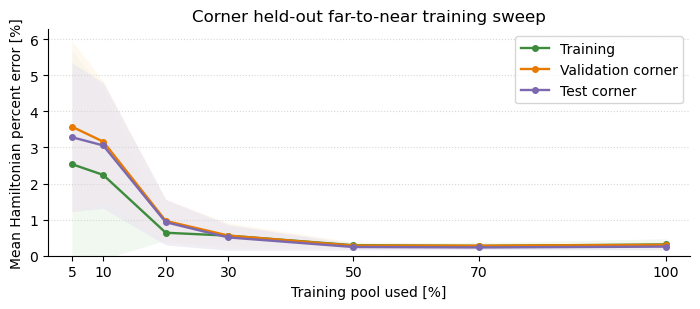

,training_percent,n_samples,train_mean,train_std,val_mean,val_std,test_mean,test_std,dist_min,dist_median,dist_max
0,5.0,68,2.537282,3.155134,3.575615,2.369318,3.283844,2.057858,0.875701,0.894634,0.971165
1,10.0,135,2.239115,2.338931,3.161729,1.684489,3.055904,1.741723,0.865682,0.875701,0.971165
2,20.0,270,0.636875,0.208029,0.964975,0.593701,0.928470,0.630159,0.852320,0.865682,0.971165
3,30.0,406,0.556325,0.262040,0.558165,0.350669,0.506954,0.357348,0.847999,0.856618,0.971165
4,50.0,676,0.290697,0.084316,0.280314,0.097886,0.241698,0.086196,0.701491,0.849622,0.971165
5,70.0,946,0.273035,0.092897,0.277155,0.072999,0.229294,0.058128,0.694915,0.847999,0.971165
6,100.0,1352,0.313202,0.157258,0.300792,0.099801,0.252292,0.082649,0.030303,0.701491,0.971165


In [9]:
summary = (
    out.groupby(["training_percent", "n_samples"], as_index=False)
    .agg(
        train_mean=("train_mean_hamiltonian_pct", "mean"),
        train_std=("train_mean_hamiltonian_pct", "std"),
        val_mean=("val_mean_hamiltonian_pct", "mean"),
        val_std=("val_mean_hamiltonian_pct", "std"),
        test_mean=("test_mean_hamiltonian_pct", "mean"),
        test_std=("test_mean_hamiltonian_pct", "std"),
        dist_min=("subset_to_test_nn_distance_min", "mean"),
        dist_median=("subset_to_test_nn_distance_median", "mean"),
        dist_max=("subset_to_test_nn_distance_max", "mean"),
    )
    .sort_values("training_percent")
)

fig, ax = plt.subplots(figsize=(7.1, 3.2))
series = [
    ("Training", "train_mean", "train_std", GREEN, GREEN_LIGHT),
    ("Validation corner", "val_mean", "val_std", ORANGE, ORANGE_LIGHT),
    ("Test corner", "test_mean", "test_std", PURPLE, PURPLE_LIGHT),
]

x = summary["training_percent"].to_numpy()
for label, mean_col, std_col, color, fill in series:
    mean = summary[mean_col].to_numpy()
    std = summary[std_col].fillna(0).to_numpy()
    ax.plot(x, mean, marker="o", markersize=4.0, linewidth=1.7, color=color, label=label)
    ax.fill_between(x, mean - std, mean + std, color=fill, alpha=0.62, linewidth=0)

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0f}" for v in x])
ax.set_xlabel("Training pool used [%]")
ax.set_ylabel("Mean Hamiltonian percent error [%]")
ax.set_title("Corner held-out far-to-near training sweep")
ax.grid(axis="y", linestyle=":", color="#D7D7D7")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", frameon=True, edgecolor="#CCCCCC", facecolor="white")
ax.set_ylim(bottom=0)
ax.margins(x=0.04)

fig.tight_layout()
fig.savefig(PLOT_DIR / "corner_far_to_near_learning_curve.pdf", bbox_inches="tight")
fig.savefig(PLOT_DIR / "corner_far_to_near_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

summary

In [10]:
def subset_for_fraction(fraction: float) -> np.ndarray:
    """Return the far-to-near training subset for a fraction."""
    if fraction in subset_indices_by_fraction:
        return subset_indices_by_fraction[fraction]

    n_subset = max(1, int(round(fraction * len(train_pool_idx))))
    subset_local = far_to_near_order[:n_subset]
    return train_pool_idx[subset_local]


def plot_fraction_3d(fraction: float, save: bool = True) -> None:
    subset_idx = subset_for_fraction(fraction)

    fig = plt.figure(figsize=(6.8, 5.4))
    ax = fig.add_subplot(111, projection="3d")

    # Grey points show training samples that are not included yet at this fraction.
    unused_idx = np.setdiff1d(train_pool_idx, subset_idx, assume_unique=False)

    ax.scatter(
        geom_raw_um[unused_idx, 0],
        geom_raw_um[unused_idx, 1],
        geom_raw_um[unused_idx, 2],
        s=10,
        c=GREY,
        alpha=0.16,
        label="not used yet",
    )
    ax.scatter(
        geom_raw_um[subset_idx, 0],
        geom_raw_um[subset_idx, 1],
        geom_raw_um[subset_idx, 2],
        s=18,
        c=GREEN,
        alpha=0.78,
        label=f"training used ({fraction:.0%})",
    )
    ax.scatter(
        geom_raw_um[val_idx, 0],
        geom_raw_um[val_idx, 1],
        geom_raw_um[val_idx, 2],
        s=24,
        c=ORANGE,
        alpha=0.88,
        label="validation corner",
    )
    ax.scatter(
        geom_raw_um[test_idx, 0],
        geom_raw_um[test_idx, 1],
        geom_raw_um[test_idx, 2],
        s=28,
        c=PURPLE,
        alpha=0.92,
        label="test corner",
    )
    ax.scatter(
        [clipped_corner_um[0]],
        [clipped_corner_um[1]],
        [clipped_corner_um[2]],
        s=180,
        marker="*",
        c=BLUE,
        edgecolor="white",
        linewidth=0.8,
        label="chosen corner",
    )

    ax.set_xlabel("claw length (µm)")
    ax.set_ylabel("ground spacing (µm)")
    ax.set_zlabel("cross length (µm)")
    ax.set_title(f"Geometry coverage at {fraction:.0%} training fraction")
    ax.view_init(elev=22, azim=-55)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)
    fig.tight_layout()

    if save:
        stem = f"geometry_3d_fraction_{int(round(fraction * 100)):03d}pct"
        fig.savefig(PLOT_DIR / f"{stem}.pdf", bbox_inches="tight")
        fig.savefig(PLOT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")

    plt.show()


def plot_fraction_pairwise(fraction: float, save: bool = True) -> None:
    subset_idx = subset_for_fraction(fraction)
    unused_idx = np.setdiff1d(train_pool_idx, subset_idx, assume_unique=False)

    pairs = [
        (0, 1, "claw length (µm)", "ground spacing (µm)"),
        (0, 2, "claw length (µm)", "cross length (µm)"),
        (1, 2, "ground spacing (µm)", "cross length (µm)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0))

    for ax, (i, j, xlabel, ylabel) in zip(axes, pairs):
        ax.scatter(geom_raw_um[unused_idx, i], geom_raw_um[unused_idx, j], s=10, c=GREY, alpha=0.16, label="not used yet")
        ax.scatter(geom_raw_um[subset_idx, i], geom_raw_um[subset_idx, j], s=18, c=GREEN, alpha=0.78, label="training used")
        ax.scatter(geom_raw_um[val_idx, i], geom_raw_um[val_idx, j], s=24, c=ORANGE, alpha=0.88, label="validation corner")
        ax.scatter(geom_raw_um[test_idx, i], geom_raw_um[test_idx, j], s=28, c=PURPLE, alpha=0.92, label="test corner")
        ax.scatter([clipped_corner_um[i]], [clipped_corner_um[j]], s=120, marker="*", c=BLUE, edgecolor="white", linewidth=0.7, label="chosen corner")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(linestyle=":", color="#D7D7D7", alpha=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=True, bbox_to_anchor=(0.5, -0.08))
    fig.suptitle(f"Pairwise geometry coverage at {fraction:.0%} training fraction", y=1.04)
    fig.tight_layout()

    if save:
        stem = f"geometry_pairwise_fraction_{int(round(fraction * 100)):03d}pct"
        fig.savefig(PLOT_DIR / f"{stem}.pdf", bbox_inches="tight")
        fig.savefig(PLOT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")

    plt.show()

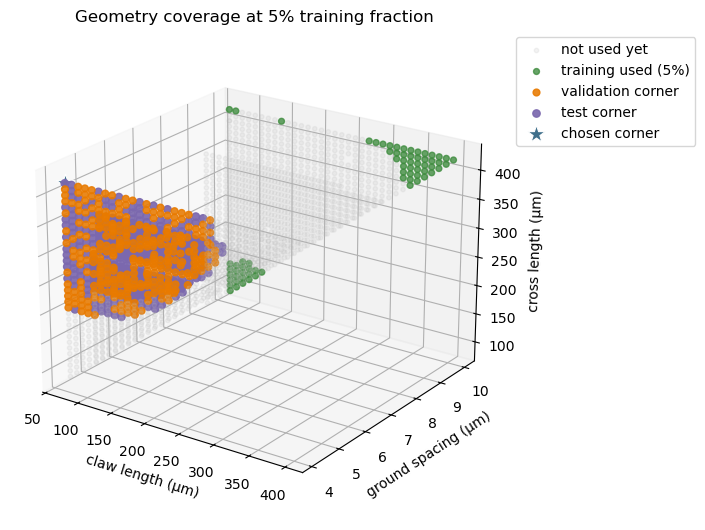

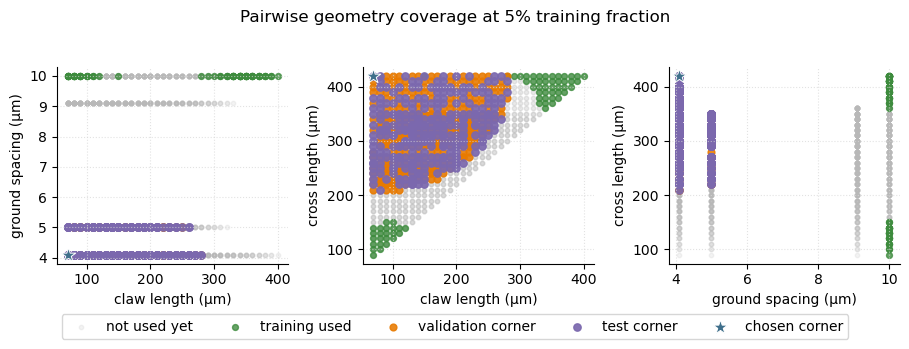

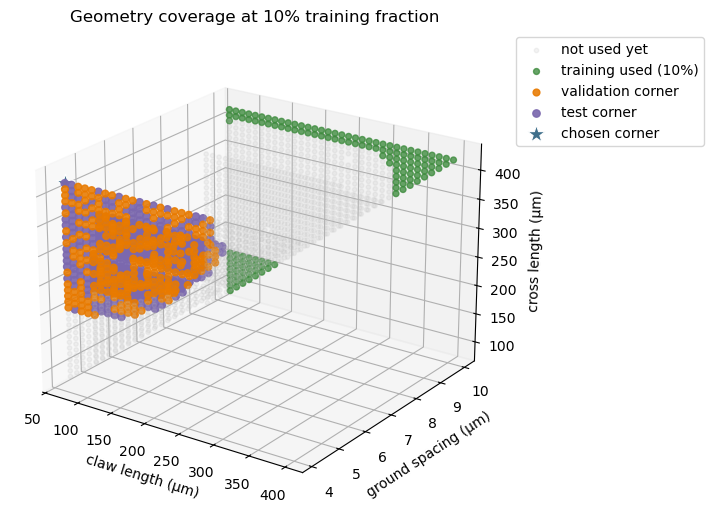

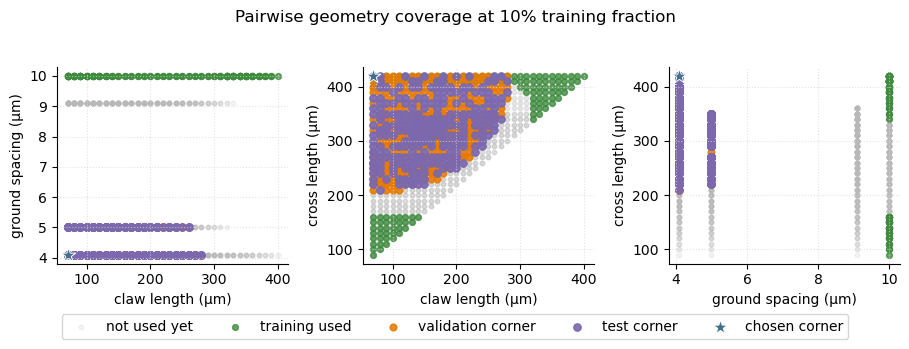

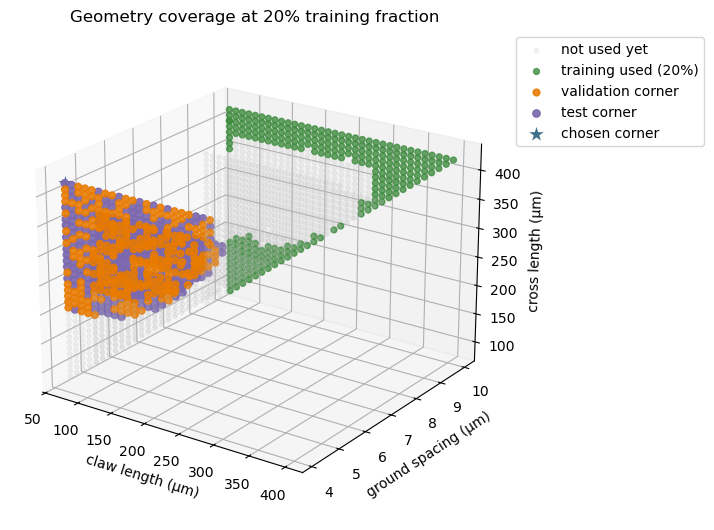

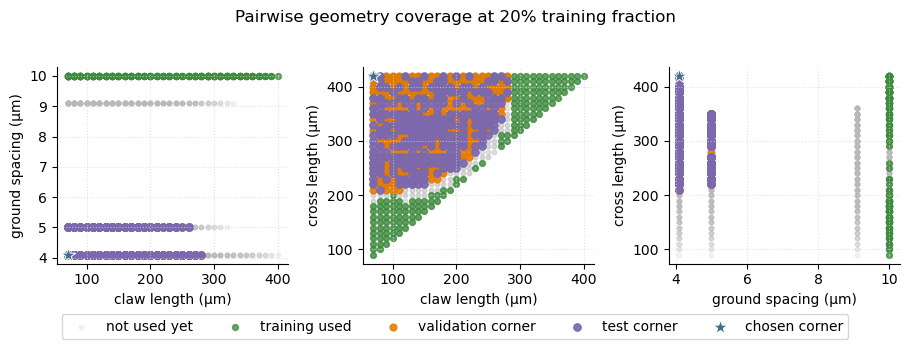

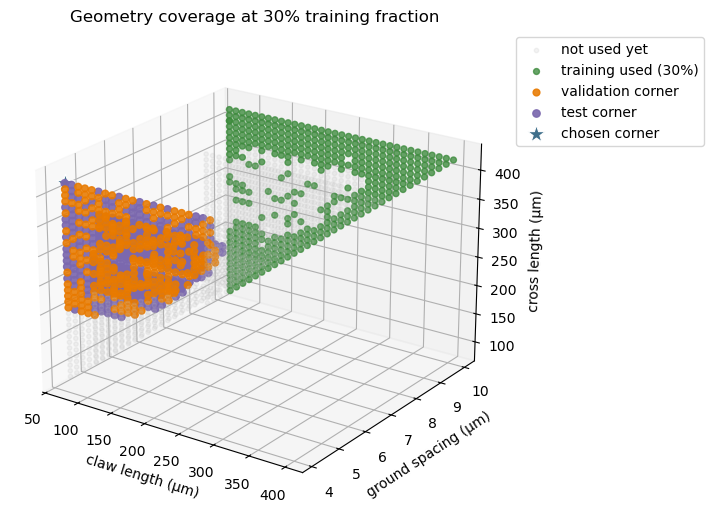

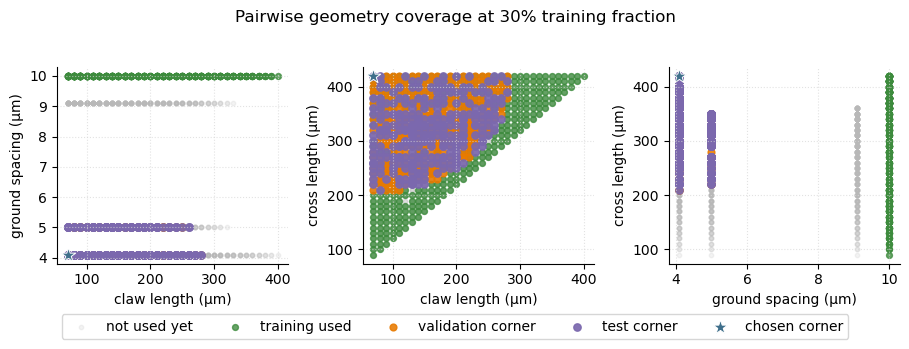

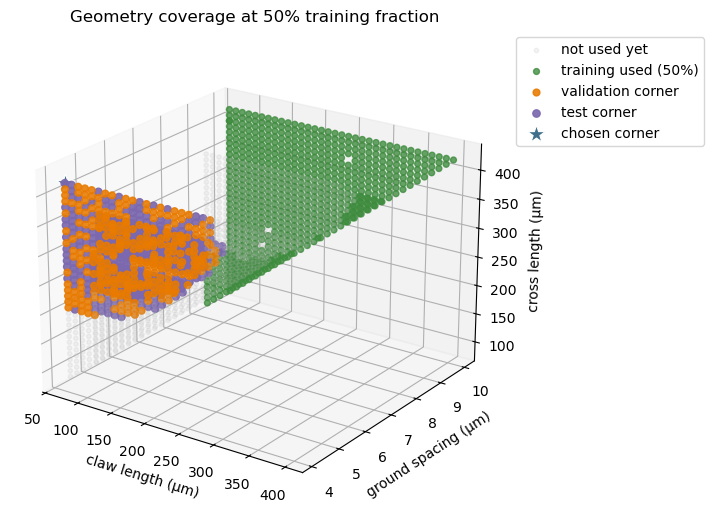

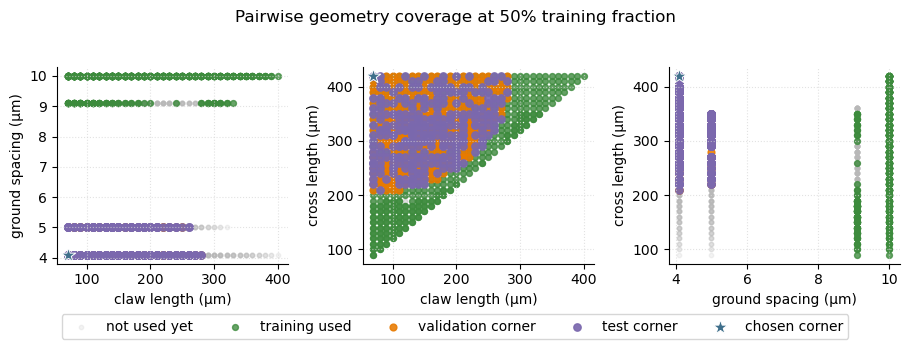

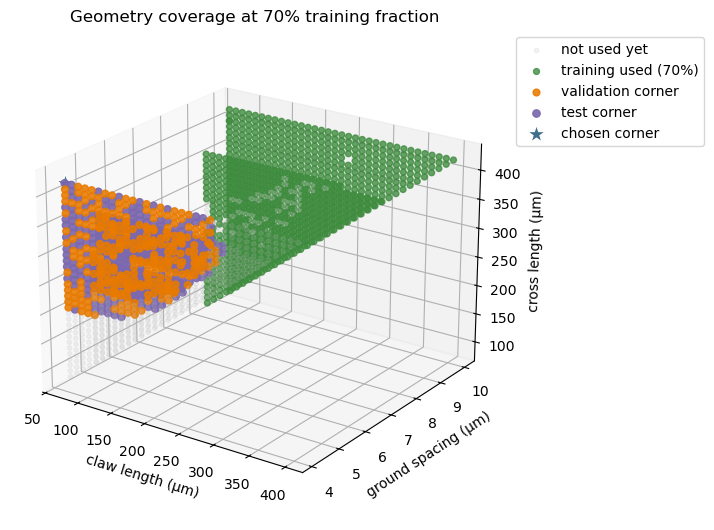

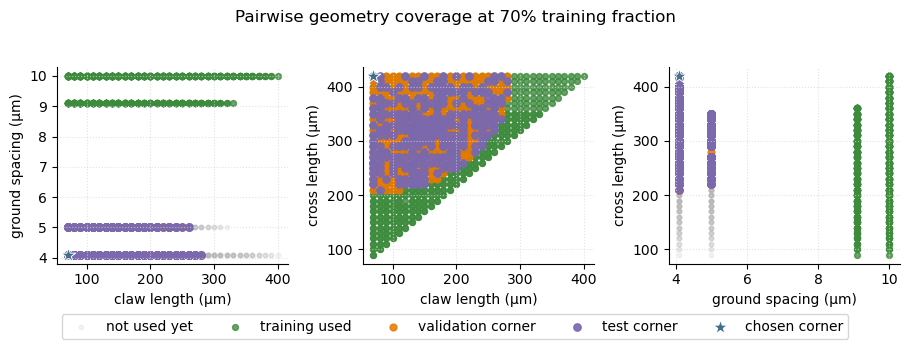

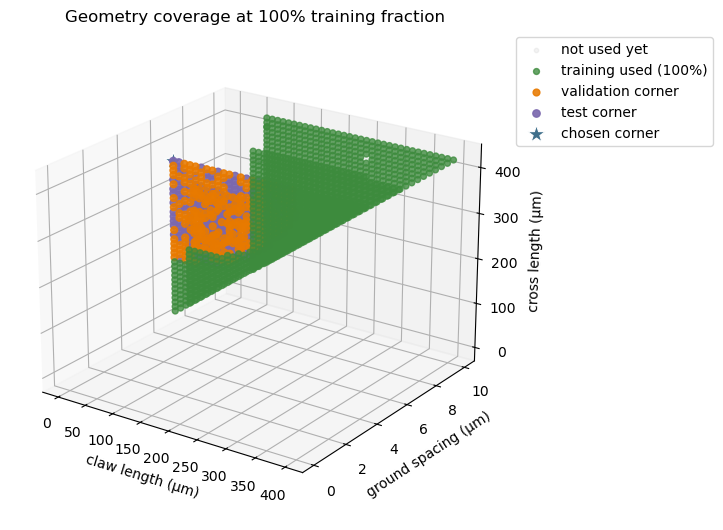

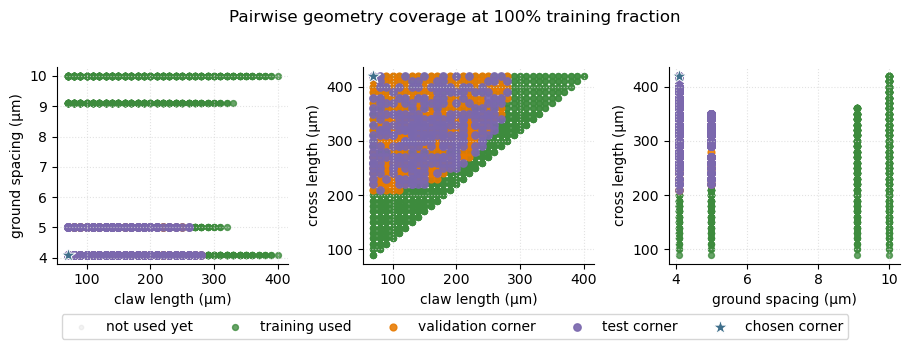

Saved fraction-by-fraction geometry plots to /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/corner_far_to_near_sweep_clean


In [11]:
# 3d plots for visualizing fractions
for fraction in FRACTIONS:
    plot_fraction_3d(fraction)
    plot_fraction_pairwise(fraction)

print(f"Saved fraction-by-fraction geometry plots to {PLOT_DIR}")

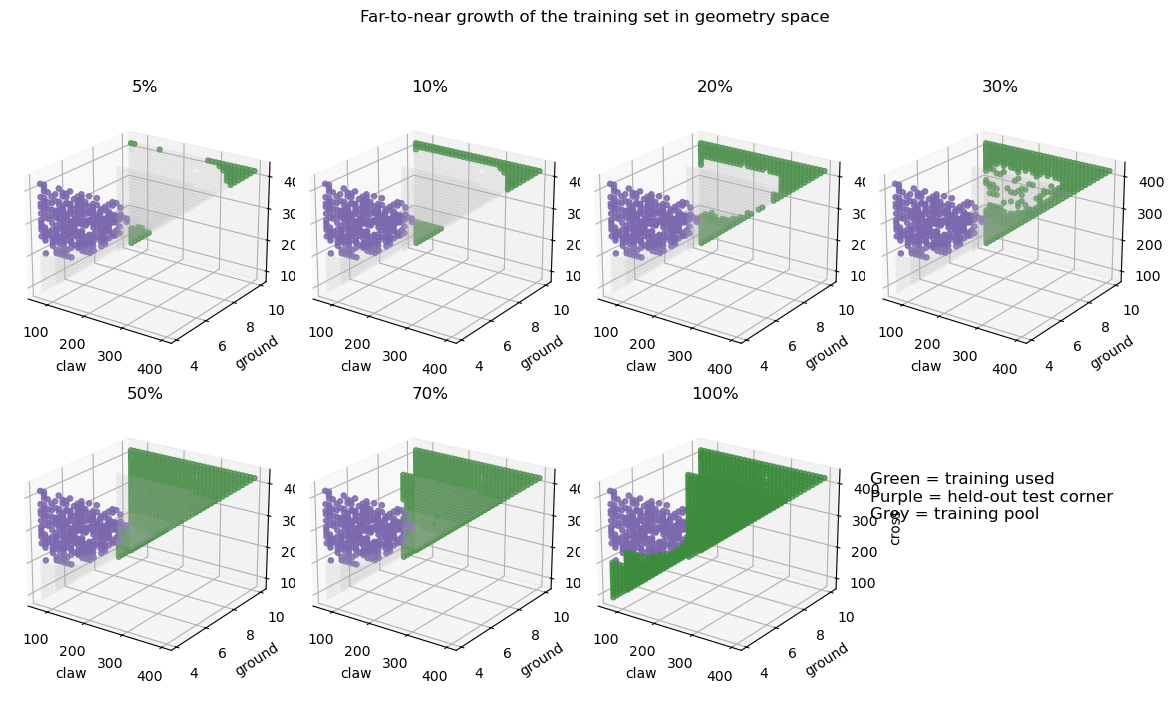

In [12]:
# everything in 1 3d fig
fig = plt.figure(figsize=(12.0, 7.2))

for panel_idx, fraction in enumerate(FRACTIONS, start=1):
    subset_idx = subset_for_fraction(fraction)
    ax = fig.add_subplot(2, 4, panel_idx, projection="3d")

    ax.scatter(
        geom_raw_um[train_pool_idx, 0],
        geom_raw_um[train_pool_idx, 1],
        geom_raw_um[train_pool_idx, 2],
        s=6,
        c=GREY,
        alpha=0.10,
    )
    ax.scatter(
        geom_raw_um[subset_idx, 0],
        geom_raw_um[subset_idx, 1],
        geom_raw_um[subset_idx, 2],
        s=12,
        c=GREEN,
        alpha=0.75,
    )
    ax.scatter(
        geom_raw_um[test_idx, 0],
        geom_raw_um[test_idx, 1],
        geom_raw_um[test_idx, 2],
        s=14,
        c=PURPLE,
        alpha=0.85,
    )
    ax.set_title(f"{fraction:.0%}")
    ax.set_xlabel("claw")
    ax.set_ylabel("ground")
    ax.set_zlabel("cross")
    ax.view_init(elev=22, azim=-55)

# Leave the last panel empty so the 7 fractions do not look cramped.
ax_empty = fig.add_subplot(2, 4, 8)
ax_empty.axis("off")
ax_empty.text(
    0.02,
    0.72,
    "Green = training used\nPurple = held-out test corner\nGrey = training pool",
    fontsize=12,
    va="top",
)

fig.suptitle("Far-to-near growth of the training set in geometry space", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(PLOT_DIR / "geometry_3d_all_fractions_panel.pdf", bbox_inches="tight")
fig.savefig(PLOT_DIR / "geometry_3d_all_fractions_panel.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
display_cols = [
    "training_percent",
    "n_samples",
    "dist_min",
    "dist_median",
    "dist_max",
    "train_mean",
    "val_mean",
    "test_mean",
]

summary[display_cols]

,training_percent,n_samples,dist_min,dist_median,dist_max,train_mean,val_mean,test_mean
0,5.0,68,0.875701,0.894634,0.971165,2.537282,3.575615,3.283844
1,10.0,135,0.865682,0.875701,0.971165,2.239115,3.161729,3.055904
2,20.0,270,0.852320,0.865682,0.971165,0.636875,0.964975,0.928470
3,30.0,406,0.847999,0.856618,0.971165,0.556325,0.558165,0.506954
4,50.0,676,0.701491,0.849622,0.971165,0.290697,0.280314,0.241698
5,70.0,946,0.694915,0.847999,0.971165,0.273035,0.277155,0.229294
6,100.0,1352,0.030303,0.701491,0.971165,0.313202,0.300792,0.252292
